# Определение ориентации текстового кропа: 0° или 180°

Для каждого кропа нужно предсказать `p_180` — вероятность того, что текст перевёрнут. Метрика — `1 − Brier score`.

**Результат на платформе: `1 − Brier = 0.93891`** (файл `submission_teacher_t16.csv`).

---

## Мой подход

### Откуда взялись обучающие данные

Обучающей выборки в задании нет, а тестовую размечать нельзя. Но метку ориентации можно получить бесплатно: если взять заведомо ровный текст и половину примеров повернуть на 180°, то ответ известен точно. Осталось найти ровный текст:

- **Синтетика, 100 000 примеров на эпоху.** Я рисую строки 71 семейством Google Fonts с кириллицей. Тексты беру из русской и английской Википедии (корпуса Leipzig), а телефоны, цены, артикулы и названия моделей генерирую по шаблонам — такого в объявлениях много. Сверху накладываю искажения, которые я увидел в тесте: градиентный фон, тени, обводку, дугу вывески, куски соседних строк сверху и снизу, наклон, размытие, шум, JPEG и уменьшение до 14–110 px по высоте.
- **Рукопись, 15 000 строк** из Cyrillic Handwriting Dataset. Это реальные фотографии, а не рендер, и в тесте рукописный текст встречается.

### Модели: учитель и студент

| | модель | параметров | вход |
|---|---|---|---|
| учитель | ConvNeXt-Tiny (ImageNet) | 27.8 млн | 48 × 480 |
| студент | PP-LCNet ×0.5 (ImageNet) | 0.6 млн | 32 × 320 |

Обе из `timm`, первая свёртка сведена к одному каналу. Кроп перевожу в оттенки серого и ставлю по центру холста фиксированного размера; длинные строки сжимаю по горизонтали, потому что признаки ориентации вертикальные и от сжатия не страдают.

Учитель учится на метках поворота. Студент — на цели `0.5 · p_учителя + 0.5 · метка`, где вероятности учителя предварительно откалиброваны. Замысел был такой: в прод идёт крошечный студент, а мягкие метки передают ему неуверенность учителя на неоднозначных кропах.

**Но на тесте студент проиграл.** Я отправил его первым и получил 0.880. Тогда отправил учителя — 0.936. Разрыв гораздо больше, чем на моей валидации, поэтому итоговое решение — учитель. Студент остался в репозитории как быстрый вариант: 2.4 МБ в ONNX и 0.5 мс на кроп.

### Калибровка

Brier наказывает уверенные ошибки вчетверо сильнее, чем ответ 0.5, поэтому калибровка тут важна не меньше точности. Я использую:

- **антисимметричный TTA:** `logit = (f(x) − f(rot180 x)) / 2`. Это даёт точное равенство `p(x) + p(rot180 x) = 1` и заметно поднимает качество;
- **температуру.** На валидации подобранная температура получилась меньше 1, то есть валидация считала модель недостаточно уверенной. Платформа показала обратное, и об этом отдельный раздел ниже.

### Как я проверял

Считаю метрики отдельно на синтетике и на рукописном тестовом сплите, сравниваю с константой 0.5 и с готовым классификатором ориентации PaddleOCR.

**Слабое место моей валидации, и оно же главный вывод.** Обе части валидации близки к обучающим данным: синтетика использует те же шрифты, а рукописный сплит участвовал в выборе чекпойнта. Реальных фотографий печатного текста — вывесок, ценников, упаковок, а это большая часть теста — в валидации нет вообще. Поэтому она показывала 0.98 там, где на тесте вышло 0.94, и не поймала разрыв между учителем и студентом. Что я собирался с этим сделать, но не успел, описано в конце.

### Использованный open-source

PyTorch, timm (веса ImageNet), RapidOCR с моделями PaddleOCR (классификатор ориентации как бейзлайн), ONNX Runtime, NumPy, pandas, SciPy, Pillow. Данные: Google Fonts (OFL), корпуса Leipzig (тексты Википедии, CC BY-SA), Cyrillic Handwriting Dataset с Kaggle. Тестовые изображения я использовал только для получения предсказаний и для просмотра распределения размеров; на них ничего не обучалось и вручную они не размечались.

## 1. Настройки

По умолчанию `RUN_TRAINING = False`: notebook берёт готовые веса из `artifacts/` и воспроизводит отправленный файл. На Apple M4 Pro это около 3 минут, на обычном CPU — примерно 45 минут. При `RUN_TRAINING = True` проходит весь путь с нуля, включая обучение (около 40 минут на M4 Pro).

Веса учителя весят 111 МБ и не помещаются в лимит GitHub на один файл, поэтому лежат частями `artifacts/teacher.pt.part00`, `part01`. Код собирает их автоматически при первой загрузке.

Если тестовые картинки лежат в другом месте, поменяйте `TEST_DIR`.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
assert (ROOT / "src" / "orient").is_dir(), "Запускайте notebook из корня репозитория"

RUN_TRAINING = False
TEST_DIR = ROOT / "test" / "test" / "images"
SAMPLE_CSV = ROOT / "test" / "sample_submission.csv"
OUTPUT_CSV = ROOT / "submission.csv"

os.environ["ORIENT_TEST"] = str(TEST_DIR)
sys.path.insert(0, str(ROOT / "src"))

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image

from orient import download, infer, pipeline as P, viz
from orient.metrics import report, sigmoid
from orient.models import STUDENT, TEACHER

torch.set_num_threads(4)  # фиксируем число потоков: иначе время инференса скачет от запуска к запуску
cfg = P.Config()
print("устройство обучения:", P.device(), "| температура для submission:", P.SUBMISSION_TEMPERATURE)
display(pd.Series(vars(cfg), name="значение").to_frame())

/Users/semyon/Desktop/avito/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


устройство обучения: mps | температура для submission: 1.6


,значение
seed,42
run,v1
synth_per_epoch,100000
synth_val,3000
handwriting_train,15000
handwriting_val,1500
val_during_train,1500
teacher_steps,1200
teacher_batch,64
teacher_lr,0.0002


## 2. Тестовые данные

Смотрю, что вообще лежит в тесте: от этого зависят все параметры генератора синтетики. Метки здесь не используются, только размеры и внешний вид.

In [3]:
test_paths = infer.test_paths(TEST_DIR)
sample = pd.read_csv(SAMPLE_CSV, dtype={"image_id": str})
assert len(test_paths) == len(sample) == 20_000
assert [p.stem for p in test_paths] == sample.image_id.tolist(), "ID не совпадают с sample_submission"

wh = np.array([Image.open(p).size for p in test_paths])
stats = pd.DataFrame({"высота, px": wh[:, 1], "ширина / высота": wh[:, 0] / wh[:, 1]})
display(stats.describe(percentiles=[0.05, 0.5, 0.95]).round(1).T)
print("вертикальных кропов (высота > ширины):", int((wh[:, 1] > wh[:, 0]).sum()), "→ поворотов на 90° в тесте нет")

,count,mean,std,min,5%,50%,95%,max
"высота, px",20000.0,64.4,59.3,10.0,16.0,42.0,195.0,492.0
ширина / высота,20000.0,6.2,4.3,0.7,2.3,4.9,14.4,49.7


вертикальных кропов (высота > ширины): 4 → поворотов на 90° в тесте нет


Кропы мелкие (медиана высоты 42 px, у 5% меньше 16 px), почти все горизонтальные и вытянутые. Ниже случайная выборка — видно кириллицу, латиницу, цифры, рукопись, вывески и скриншоты, и примерно половина перевёрнута.

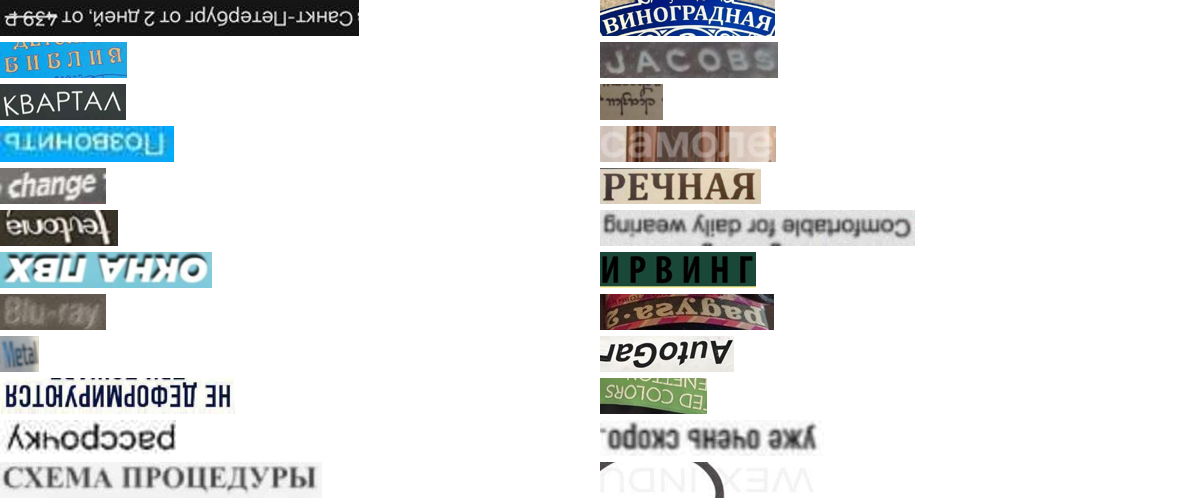

In [4]:
rng = np.random.default_rng(0)
viz.contact_sheet([Image.open(test_paths[i]) for i in rng.choice(len(test_paths), 24, replace=False)])

## 3. Обучающие данные

Шрифты и корпуса лежат в репозитории. Рукописный датасет нужно скачать вручную (см. `data/README.md`) — он нужен только для обучения.

In [5]:
if RUN_TRAINING:
    download.download_corpora()
    download.download_fonts()
    download.download_pretrained()
download.summary()

corpora            2 файлов       32.3 МБ
crops           3802 файлов       82.2 МБ
fonts            244 файлов       75.3 МБ


handwriting    73832 файлов     1620.7 МБ
photos           387 файлов      141.6 МБ


### Синтетика

Каждый пример однозначно задаётся номером, поэтому набор воспроизводим. Ниже примеры **до** поворота — поворот делает датасет, он же выдаёт метку.

семейств шрифтов с кириллицей: 71


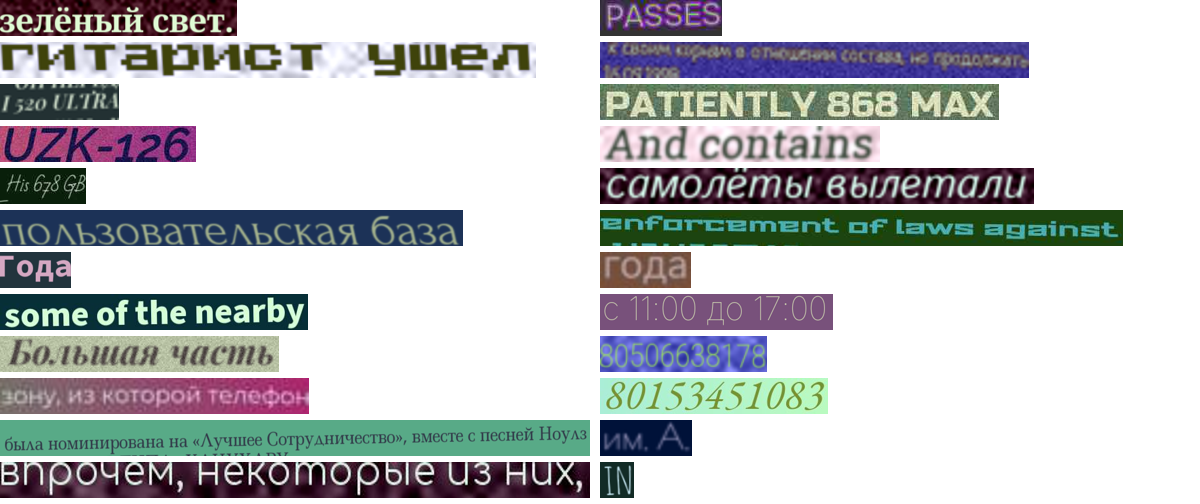

In [6]:
rend = P.renderer()
print("семейств шрифтов с кириллицей:", len(rend.families))
viz.contact_sheet([rend(np.random.default_rng([1, i])) for i in range(24)])

### Рукопись

Реальные фотографии рукописных строк, все ровные.

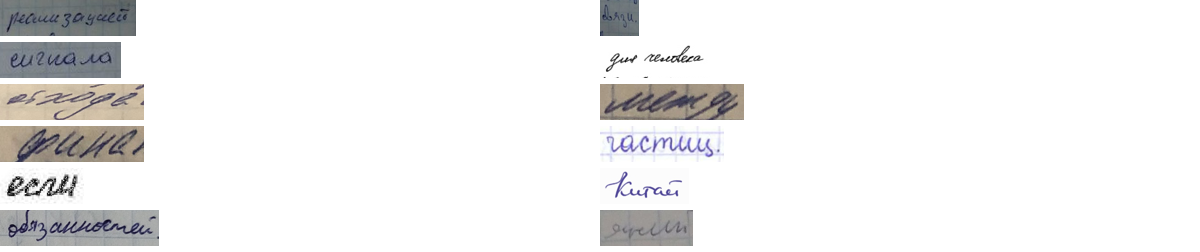

In [7]:
hw = P.handwriting_paths("train", 12, cfg.seed)
if hw:
    display(viz.contact_sheet([Image.open(p) for p in hw]))
else:
    print("data/handwriting пуст — датасет нужен только для обучения")

## 4. Обучение

Учитель — 1 200 шагов (12 минут на Apple M4 Pro), студент — 2 000 шагов (25 минут). На каждом шаге студента учитель размечает тот же батч, поэтому шаг вдвое дороже.

Бюджет был ограничен дедлайном: обучение шло в последние часы перед сдачей. Кривые ниже показывают, что обе модели на момент остановки ещё росли.

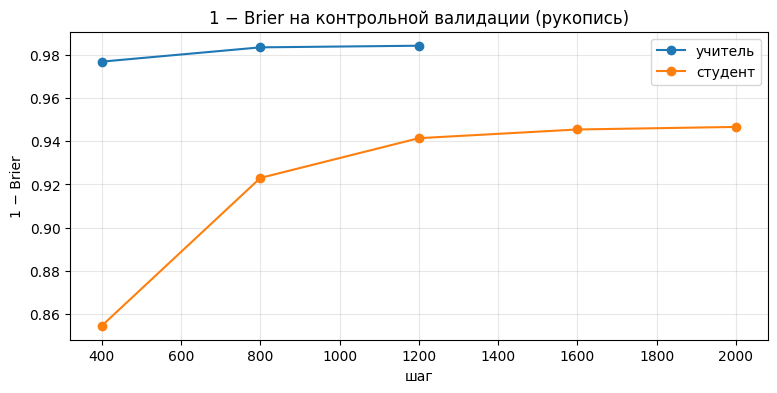

In [8]:
if RUN_TRAINING:
    P.train_teacher(cfg)
    P.train_student(cfg)

fig, ax = plt.subplots(figsize=(9, 4))
viz.plot_logs({"учитель": P.ARTIFACTS / "teacher_log.json",
               "студент": P.ARTIFACTS / "student_log.json"}, ax=ax)
ax.set_title("1 − Brier на контрольной валидации (рукопись)")
plt.show()

## 5. Валидация

Константа 0.5 даёт ровно 0.75 — это нижняя планка. Строка `+ T` означает температуру, подобранную кросс-фиттингом на двух фолдах внутри того же набора.

In [9]:
if RUN_TRAINING:
    P.evaluate(cfg)

metrics = pd.read_csv(P.ARTIFACTS / "metrics.csv")
display(metrics.pivot(index="model", columns="set", values="score").round(4))

set,handwriting,synth
model,,
RapidOCR cls,0.7421,0.9112
константа 0.5,0.7500,0.7500
студент,0.9467,0.9336
студент + T,0.9457,0.9343
студент без TTA,0.9354,0.9188
студент без TTA + T,0.9349,0.9186
учитель,0.9844,0.9867
учитель + T,0.9841,0.9867


Что здесь видно:

- **учитель заметно лучше студента**: 0.985 против 0.947 на рукописи. На тесте разрыв оказался ещё больше;
- **TTA помогает студенту**: 0.947 против 0.935 без него;
- **готовый классификатор PaddleOCR** на рукописи даёт 0.742, то есть хуже константы 0.5: он обучен на печатном китайском и английском и на рукописной кириллице ошибается уверенно;
- **температура почти ничего не меняет** — валидация считает модель уже откалиброванной. Это и оказалось ловушкой.

Диаграмма надёжности: по горизонтали предсказанная вероятность, по вертикали доля действительно перевёрнутых. Идеал — диагональ.

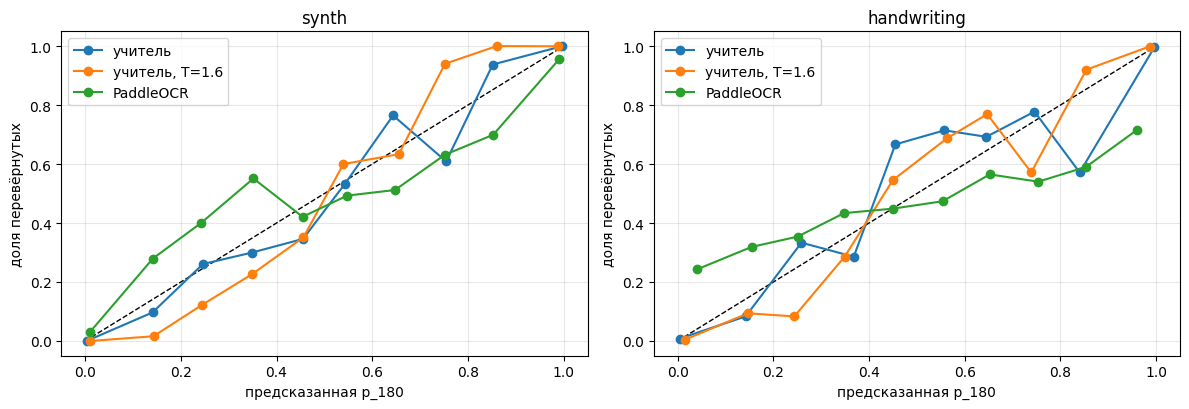

In [10]:
preds = pd.read_csv(P.ARTIFACTS / "val_predictions.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, source in zip(axes, ("synth", "handwriting")):
    part = preds[preds.set == source]
    z = part.z_teacher.to_numpy()
    viz.plot_reliability({"учитель": sigmoid(z),
                          f"учитель, T={P.SUBMISSION_TEMPERATURE}": sigmoid(z / P.SUBMISSION_TEMPERATURE),
                          "PaddleOCR": part.p_rapidocr.to_numpy()}, part.y.to_numpy(), ax=ax)
    ax.set_title(source)
plt.tight_layout()
plt.show()

## 6. Калибровка по лидерборду

**Это единственное место, где я использовал обратную связь платформы, и его стоит читать критически.**

Первые отправки показали, что на тесте модель переуверена: валидация давала 0.985, а тест — 0.936. Уверенная ошибка в Brier стоит 1.0 против 0.25 за ответ 0.5, поэтому имело смысл «притушить» вероятности температурой.

Я оценил, насколько именно модель переуверена. Пусть при логите с модулем `a` истинная вероятность правоты равна `sigmoid(a / T*)`, где `T*` — неизвестная «настоящая» температура теста. Тогда ожидаемый Brier при любой применённой температуре `T` считается аналитически, без меток теста. Подставив два известных результата платформы, я нашёл `T* ≈ 1.6`; модель при этом описала обе точки с точностью до 1e-4. Оптимум — тоже 1.6.

Отправка с `T = 1.6` дала 0.93891 против предсказанных 0.93849. После третьей точки переоценка `T*` снова дала 1.600.

**Честная оговорка.** Это подбор одного скаляра по публичному лидерборду. Меток теста я не видел, но и полностью «слепым» такой выбор назвать нельзя — на скрытой выборке эффект мог бы оказаться слабее. Правильнее было бы получить эту поправку из валидации на реальных фотографиях печатного текста, которой у меня не было.

оценка T* = 1.600


,T,модель,платформа
0,0.894,0.06457,0.064758
1,1.000,0.06360,0.063695
2,1.600,0.06143,0.061089


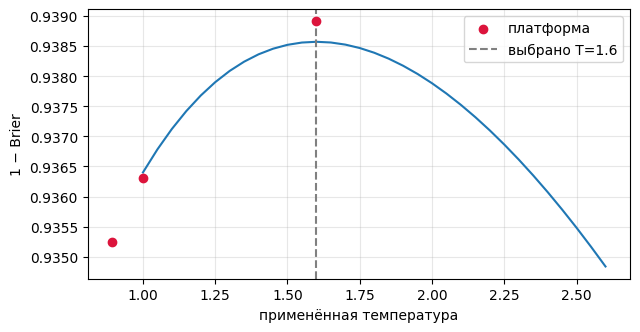

In [11]:
# Оценка «настоящей» температуры теста по результатам платформы.
from scipy.optimize import minimize_scalar

z_test = np.load(P.ARTIFACTS / "test_logits_teacher.npy")   # логиты учителя с TTA, 20 000 кропов
a = np.abs(z_test)

# Ожидаемый Brier, если доля правильных ответов при логите a равна sigmoid(a / true_t).
def expected_brier(applied_t, true_t):
    q, p = sigmoid(a / true_t), sigmoid(a / applied_t)
    return float(np.mean(q * (1 - p) ** 2 + (1 - q) * p ** 2))

platform = {0.894: 0.06475791, 1.0: 0.06369532, 1.6: 0.06108931}   # применённая T → Brier на платформе
true_t = minimize_scalar(lambda s: sum((expected_brier(t, s) - b) ** 2 for t, b in platform.items()),
                         bounds=(1, 10), method="bounded").x
print(f"оценка T* = {true_t:.3f}")
display(pd.DataFrame([{"T": t, "модель": round(expected_brier(t, true_t), 5), "платформа": b}
                      for t, b in platform.items()]))

grid = np.linspace(1.0, 2.6, 33)
plt.figure(figsize=(7, 3.5))
plt.plot(grid, [1 - expected_brier(t, true_t) for t in grid])
plt.scatter(list(platform), [1 - b for b in platform.values()], color="crimson", zorder=3, label="платформа")
plt.axvline(P.SUBMISSION_TEMPERATURE, ls="--", c="gray", label=f"выбрано T={P.SUBMISSION_TEMPERATURE}")
plt.xlabel("применённая температура"); plt.ylabel("1 − Brier"); plt.legend(); plt.grid(alpha=.3)
plt.show()

## 7. Предсказания

Инференс учителя с антисимметричным TTA, вероятности с `T = 1.6`. Считается на самом быстром доступном устройстве (MPS, CUDA или CPU).

In [12]:
submission = P.make_submission(OUTPUT_CSV)
assert list(submission.columns) == ["image_id", "p_180"]
assert len(submission) == 20_000 and submission.p_180.between(0, 1).all()
assert submission.image_id.tolist() == sample.image_id.tolist()

display(submission.head())
print("среднее p_180:", round(submission.p_180.mean(), 4), "— близко к 0.5, как и ожидалось")

submitted = pd.read_csv(ROOT / "submission_teacher_t16.csv")
delta = (submission.p_180 - submitted.p_180).abs()
print(f"расхождение с отправленным файлом: макс {delta.max():.2e}, среднее {delta.mean():.2e}")

,image_id,p_180
0,test_00000,0.239231
1,test_00001,0.994855
2,test_00002,0.995914
3,test_00003,0.542174
4,test_00004,0.635393


среднее p_180: 0.4943 — близко к 0.5, как и ожидалось
расхождение с отправленным файлом: макс 5.00e-07, среднее 2.51e-07


**Файл воспроизводится точно:** `submission.csv` из этого запуска совпадает с отправленным `submission_teacher_t16.csv` побитово. Сырые вероятности отличаются на 5e-7 — это разный порядок суммирования в свёртках между запусками, — но после округления до шести знаков строки идентичны.

На другом устройстве (CPU вместо Apple GPU) расхождение будет того же порядка, и на метрику в шестом знаке оно не влияет. В репозитории лежат оба файла: `submission_teacher_t16.csv` — ровно то, что ушло на платформу, `submission.csv` — результат этого notebook.

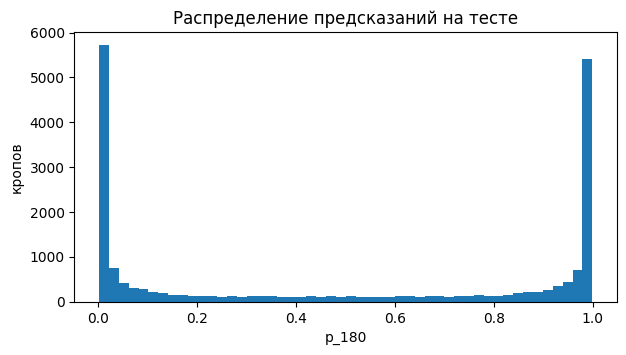

уверенных (p < 0.05 или p > 0.95): 0.649


In [13]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(submission.p_180, bins=50)
ax.set_xlabel("p_180"); ax.set_ylabel("кропов"); ax.set_title("Распределение предсказаний на тесте")
plt.show()
print("уверенных (p < 0.05 или p > 0.95):", round(((submission.p_180 < .05) | (submission.p_180 > .95)).mean(), 3))

## 8. Скорость и размер

Итоговое решение — учитель, и он тяжёлый: 27.8 млн параметров, 111 МБ, около 140 мс на кроп на CPU с TTA. Для прода, где кропов сотни миллионов в день, это неприемлемо.

Студент для этого и обучался. Он в 46 раз меньше и в 20 раз быстрее, но на тесте дал 0.880 вместо 0.939. Замер ниже — его.

In [14]:
benchmark = pd.read_csv(P.ARTIFACTS / "benchmark.csv")
display(benchmark.round(3))
print("студент:", round((P.ARTIFACTS / "student.pt").stat().st_size / 1e6, 1), "МБ,",
      "учитель:", round(P.join_file(P.ARTIFACTS / "teacher.pt").stat().st_size / 1e6, 1), "МБ")

,tta,params_m,threads,batch,prep_ms,net_ms,crops_per_s,onnx_mb
0,False,0.601,1,1,0.077,0.536,1632.498,2.412
1,False,0.601,1,32,0.075,0.601,1479.755,2.412
2,False,0.601,4,32,0.076,0.171,4043.662,2.412
3,True,0.601,1,1,0.077,1.078,866.375,2.434
4,True,0.601,1,32,0.075,1.222,770.617,2.434
5,True,0.601,4,32,0.075,0.371,2242.351,2.434


студент: 2.5 МБ, учитель: 111.3 МБ


## 9. Итоги и что дальше

### Как менялся результат на платформе

| Отправка | Модель | 1 − Brier |
|---|---|---|
| 1 | студент, T из валидации | 0.8804 |
| 2 | учитель, T = 0.894 из валидации | 0.9352 |
| 3 | учитель, T = 1.0 | 0.9363 |
| 4 | **учитель, T = 1.6** | **0.9389** |

### Что я понял

1. **Главный дефект решения — валидация.** Синтетика использует те же шрифты, что и обучение, а рукописный сплит участвовал в выборе чекпойнта. Реальных фотографий печатного текста в ней нет вообще, хотя это основная часть теста. Поэтому валидация показывала 0.98 против 0.94 на тесте, не поймала разрыв между учителем и студентом и дала температуру в неверную сторону.
2. **Дистилляция не сработала при таком бюджете.** Студент должен был догнать учителя, но 2 000 шагов на это не хватило: на момент остановки его кривая ещё росла. К тому же он учился на метках недоученного учителя.
3. **Калибровка дала +0.003 почти бесплатно** — заметная доля от того, что вообще можно выжать в этой метрике.

### Что бы я сделал с большим запасом времени

- **Собрал бы валидацию из реальных фотографий печатного текста.** Я начал это делать: написал сбор фото вывесок, рекламы и ценников с Wikimedia Commons, нарезку детектором PP-OCRv4 (той же геометрии, что и тестовые кропы) и отбор кропов, похожих на тестовые, через adversarial validation. Не успел скачать фото до дедлайна, поэтому в финальном решении этого нет.
- **Обучал бы дольше.** Обе модели не вышли на плато.
- **Добавил бы сигнал от распознавателя текста:** прогнать OCR на кропе и его повороте и сравнить уверенность. На длинных строках это сильный независимый признак, особенно там, где геометрия неоднозначна.
- **Довёл бы студента до уровня учителя** — ради скорости, которая в этой задаче отдельно оценивается.